<a href="https://colab.research.google.com/github/lucasmerotto/AprendizadoM-quina-Trabalho_Pratico/blob/main/Trabalho2_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Início com as importação necessárias para o spot-checking

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*Found unknown categories.*")

from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import classification_report, RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# Reprodutibilidade
RANDOM_STATE = 45

Importação do dataset através do Google Drive, apresentação das 5 primeiras linhas iniciais e verificação de atributos faltantes

In [ ]:
import pandas as pd
from google.colab import files


uploaded = files.upload()


df = pd.read_csv('team_stats_2003_2023_modified5.csv', sep=';', encoding='utf-8')

print(df.head())

print(df.isna().sum())

Saving team_stats_2003_2023_modified5.csv to team_stats_2003_2023_modified5 (1).csv
                team  win_loss_perc  win_loss_perc_3yrs  points  points_opp  \
0  Arizona Cardinals          0.250               0.313     225         452   
1  Arizona Cardinals          0.375               0.333     284         322   
2  Arizona Cardinals          0.313               0.313     311         387   
3  Arizona Cardinals          0.313               0.396     314         389   
4  Arizona Cardinals          0.500               0.334     404         399   

   points_diff   g  total_yards  plays_offense  yds_per_play_offense  ...  \
0         -227  16         4490            981                    46  ...   
1          -38  16         4550           1047                    43  ...   
2          -76  16         5575           1075                    52  ...   
3          -75  16         5000            999                    50  ...   
4            5  16         5505           1016          

Verificação de atributos faltantes e frequência da porcentagem de vitórias (atributo-alvo)

In [ ]:
#Verificar se há valores nulos
df.info()
#Descrição da quantidade de dados não nulos por atributo e seu tipo
df.describe()
#Verificar quantas vezes aconteceram cada porcentagens de vitória ao longo do dataset
df['win_loss_perc'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   team                  672 non-null    object 
 1   win_loss_perc         672 non-null    float64
 2   win_loss_perc_3yrs    672 non-null    float64
 3   points                672 non-null    int64  
 4   points_opp            672 non-null    int64  
 5   points_diff           672 non-null    int64  
 6   g                     672 non-null    int64  
 7   total_yards           672 non-null    int64  
 8   plays_offense         672 non-null    int64  
 9   yds_per_play_offense  672 non-null    int64  
 10  turnovers             672 non-null    int64  
 11  fumbles_lost          672 non-null    int64  
 12  first_down            672 non-null    int64  
 13  pass_cmp              672 non-null    int64  
 14  pass_att              672 non-null    int64  
 15  pass_yds              6

,count
win_loss_perc,
0.500,63
0.438,63
0.625,60
0.563,54
0.375,51
0.250,47
0.688,47
0.313,47
0.750,42


Plotagem do gráfico de distribuição da taxa de vitórias

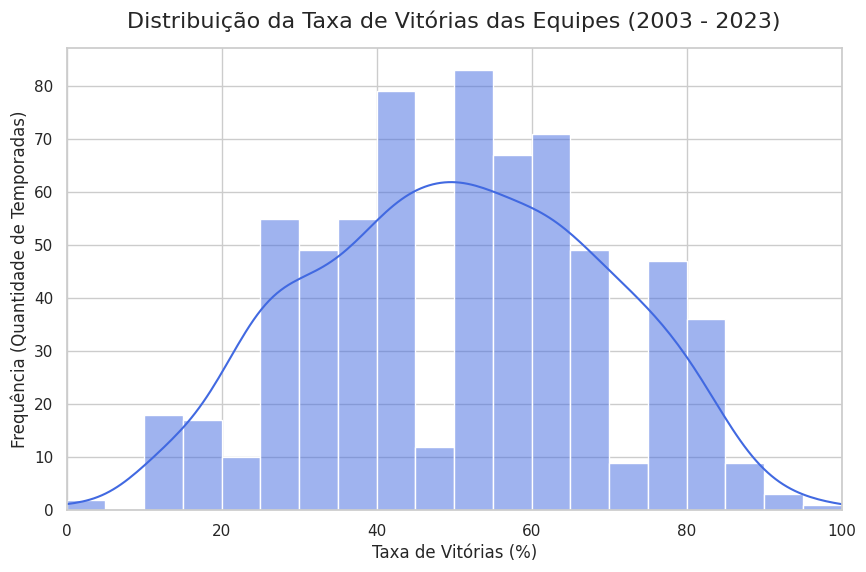

In [ ]:
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

porcentagens = df['win_loss_perc'] * 100


ax = sns.histplot(porcentagens, bins=20, kde=True, color='royalblue')

plt.title('Distribuição da Taxa de Vitórias das Equipes (2003 - 2023)', fontsize=16, pad=15)
plt.xlabel('Taxa de Vitórias (%)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Temporadas)', fontsize=12)


plt.xlim(0, 100)


plt.show()

Divisão entre dados e atributo-alvo

In [ ]:
counts = df['win_loss_perc'].value_counts()
df_filtrado = df[df['win_loss_perc'].isin(counts[counts >= 2].index)]
X = df_filtrado.drop('win_loss_perc', axis=1) # Tudo, menos o alvo
y = df_filtrado['win_loss_perc']

Definição do pré-processamento, utilizando MinMaxScaler para normalização e OneHotEncoder para codificação de categorias

In [ ]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(feature_range=(0, 1)), numerical_cols),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), categorical_cols)
    ]
)


Divisão entre treino e teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (533, 30)
Test shape: (134, 30)


Spot-Checking de algoritmos

In [ ]:
from sklearn.linear_model import Ridge

models = {
    "K3NN": KNeighborsRegressor(n_neighbors=3),
    "K5NN": KNeighborsRegressor(),
    "LinearRegression": LinearRegression(),
    "LinearRegressionRidge": Ridge(alpha=0.04),
    "DecisionTree": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE), #max_depth = 10 é usado para tentar evitar o overfitting
    "DecisionTreeSemPoda": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "NeuralNetwork": MLPRegressor(max_iter=500, early_stopping=True, n_iter_no_change=10,random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(max_depth=10, random_state=RANDOM_STATE),
    "RandomForestSemPoda": RandomForestRegressor(random_state=RANDOM_STATE),
    "RandomForestOtimizada": RandomForestRegressor(max_depth=6, random_state=RANDOM_STATE, n_estimators=190, min_samples_split=5, min_samples_leaf=2)
}

cv = KFold(n_splits=5, random_state=RANDOM_STATE, shuffle=True)

results = {}
results_raw = {}
results_mse ={}

print("\n===== SPOT-CHECKING =====")

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    scores_mse = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    results_raw[name] = scores

    results[name] = {
        'mean': scores.mean(),
        'std': scores.std()
    }
    results_mse[name] = {
        'mean': scores_mse.mean(),
        'std': scores_mse.std()
    }

    mae_min = -scores.mean()
    mse_min = -scores_mse.mean()
    print(f"{name}: MAE Médio={mae_min:.4f}")
    print(f"{name}: MSE Médio={mse_min:.4f}")

    print()


===== SPOT-CHECKING =====
K3NN: MAE Médio=0.1191
K3NN: MSE Médio=0.0224

K5NN: MAE Médio=0.1146
K5NN: MSE Médio=0.0211

LinearRegression: MAE Médio=0.0704
LinearRegression: MSE Médio=0.0085

LinearRegressionRidge: MAE Médio=0.0699
LinearRegressionRidge: MSE Médio=0.0084

DecisionTree: MAE Médio=0.0950
DecisionTree: MSE Médio=0.0154

DecisionTreeSemPoda: MAE Médio=0.0936
DecisionTreeSemPoda: MSE Médio=0.0156

NeuralNetwork: MAE Médio=0.0816
NeuralNetwork: MSE Médio=0.0111

RandomForest: MAE Médio=0.0692
RandomForest: MSE Médio=0.0081

RandomForestSemPoda: MAE Médio=0.0689
RandomForestSemPoda: MSE Médio=0.0081

RandomForestOtimizada: MAE Médio=0.0689
RandomForestOtimizada: MSE Médio=0.0080



Geração e plotagem do gráfico boxplot

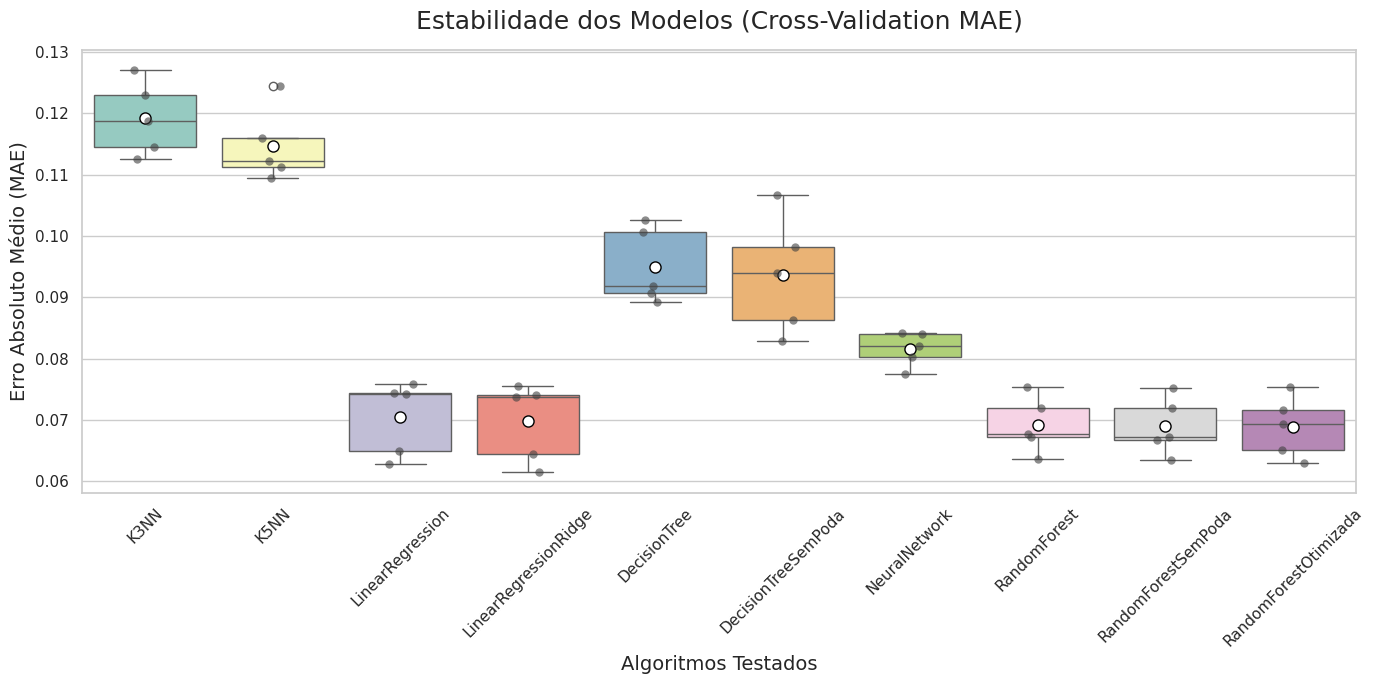

In [ ]:

dados_grafico = []

for nome_modelo, scores in results_raw.items():

    erros_positivos = -scores


    for erro in erros_positivos:
        dados_grafico.append({'Modelo': nome_modelo, 'MAE': erro})

df_box = pd.DataFrame(dados_grafico)


plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")


sns.boxplot(x='Modelo', y='MAE', data=df_box,
            palette='Set3', showmeans=True,
            meanprops={"marker":"o",
                       "markerfacecolor":"white",
                       "markeredgecolor":"black",
                       "markersize":"8"})


sns.stripplot(x='Modelo', y='MAE', data=df_box, color=".25", size=6, alpha=0.6, jitter=True)


plt.title('Estabilidade dos Modelos (Cross-Validation MAE)', fontsize=18, pad=15)
plt.ylabel('Erro Absoluto Médio (MAE)', fontsize=14)
plt.xlabel('Algoritmos Testados', fontsize=14)


plt.xticks(rotation=45)
plt.tight_layout()


plt.show()

Abertura dos coeficientes da regressão linear

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

pipeline_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])
pipeline_lr.fit(X_train, y_train)


modelo_lr = pipeline_lr.named_steps['model']
nomes_colunas = pipeline_lr.named_steps['preprocessing'].get_feature_names_out()


coeficientes = modelo_lr.coef_
intercepto = modelo_lr.intercept_


tabela_coeficientes = pd.DataFrame({
    'Estatistica': nomes_colunas,
    'Peso (Coeficiente)': coeficientes
})


tabela_coeficientes = tabela_coeficientes.sort_values(by='Peso (Coeficiente)', key=abs, ascending=False)

print(f"--- REGRESSÃO LINEAR ---")
print(f"Ponto de Partida (Intercepto): {intercepto:.4f}\n")
print("Tabela de Pesos das Estatísticas:")
print(tabela_coeficientes.to_string(index=False))

--- REGRESSÃO LINEAR ---
Ponto de Partida (Intercepto): 0.0769

Tabela de Pesos das Estatísticas:
                    Estatistica  Peso (Coeficiente)
                  num__rush_att            0.509109
               num__points_diff            0.420667
               num__total_yards           -0.395604
                  num__rush_yds           -0.360137
                    num__points            0.349701
                  num__pass_att            0.242653
      num__pass_net_yds_per_att            0.228711
                  num__pass_yds           -0.213563
                num__points_opp           -0.193599
          num__rush_yds_per_att            0.178242
             num__plays_offense           -0.146686
              num__turnover_pct           -0.140528
                   num__pass_fd            0.133538
      num__yds_per_play_offense            0.113494
                num__first_down            0.095115
                  num__pass_cmp            0.070598
     cat__team_Los

# Otimização de Hiperparêmtros

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import time

print("Iniciando a Otimização de Hiperparâmetros\n")

# ==========================================
# 1. OTIMIZANDO O RANDOM FOREST
# ==========================================
print("1. Treinando e testando combinações do Random Forest (Isso pode levar alguns minutos)...")
start_time = time.time()

# Pipeline do RF (random forest)
pipeline_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))
])

# A "Grade" de parâmetros que queremos testar
# O prefixo 'model__' é necessário porque o modelo está dentro do Pipeline
param_grid_rf = {
    'model__n_estimators': [190, 200, 210],       # Número de árvores
    'model__max_depth': [4, 5, 6, 7],             # Profundidade (None = sem limite)
    'model__min_samples_split': [4, 5, 6],        # Mínimo de exemplos para dividir um nó
    'model__min_samples_leaf': [1, 2, 3]          # Mínimo de exemplos na ponta da folha
}

# Configurando a busca (n_jobs=-1 para otimização da máquina)
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)

tempo_rf = time.time() - start_time
print(f"-> RF Finalizado em {tempo_rf:.1f} segundos")
print(f"-> Melhor MAE do RF: {-grid_rf.best_score_:.4f}")
print(f"-> Melhores Parâmetros: {grid_rf.best_params_}\n")


# ==========================================
# 2. OTIMIZANDO A REGRESSÃO (RIDGE)
# ==========================================
print("2. Treinando e testando combinações da Regressão Ridge")

# Pipeline do Ridge
pipeline_ridge = Pipeline([
    ('preprocessing', preprocessor),
    ('model', Ridge(random_state=RANDOM_STATE))
])

# O hiperparâmetro alpha controla a força da regularização
param_grid_ridge = {
    'model__alpha': [0.01, 0.02, 0.03, 0.04, 0.05, 0.025]
}

grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_ridge.fit(X_train, y_train)

print(f"-> Melhor MAE do Ridge: {-grid_ridge.best_score_:.4f}")
print(f"-> Melhor Parâmetro (Alpha): {grid_ridge.best_params_}\n")

# ==========================================
# 3. SALVANDO OS MODELOS OTIMIZADOS
# ==========================================
melhor_rf = grid_rf.best_estimator_
melhor_ridge = grid_ridge.best_estimator_

Iniciando a Otimização de Hiperparâmetros...

1. Treinando e testando combinações do Random Forest (Isso pode levar alguns minutos)...
-> RF Finalizado em 324.9 segundos!
-> Melhor MAE do RF: 0.0685
-> Melhores Parâmetros: {'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 6, 'model__n_estimators': 210}

2. Treinando e testando combinações da Regressão Ridge...
-> Melhor MAE do Ridge: 0.0702
-> Melhor Parâmetro (Alpha): {'model__alpha': 0.05}



# Avaliação de desempenho

=== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===
MAE Final (Erro Médio Absoluto): 0.0697 (ou 7.0%)
MSE Final (Erro Quadrático):     0.0080
R² (Coeficiente de Explicação):  0.7634

--- Top 10 Previsões Mais Precisas ---


,Win % Real,Win % Previsto,Erro (Diferença)
4,0.500,0.501124,0.001124
612,0.250,0.247775,0.002225
69,0.375,0.378637,0.003637
158,0.438,0.433814,0.004186
27,0.563,0.567989,0.004989
195,0.500,0.505610,0.005610
273,0.750,0.743600,0.006400
111,0.438,0.429604,0.008396
437,0.438,0.448023,0.010023
314,0.529,0.518460,0.010540


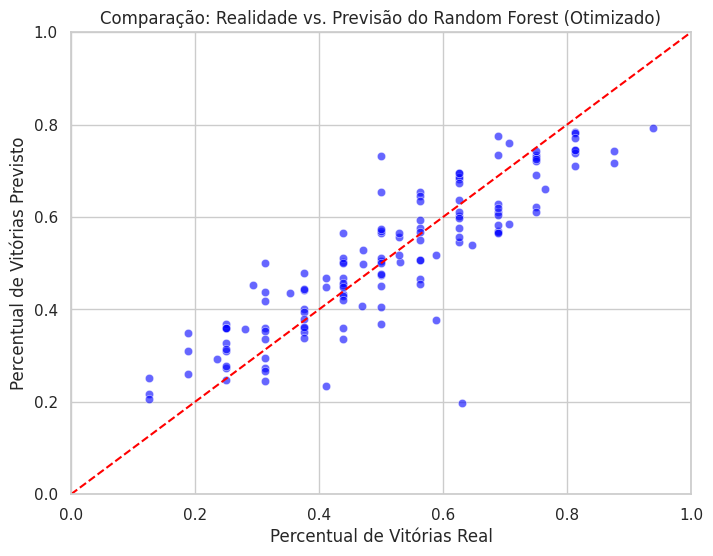

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===")

# 1. Definindo o modelo explicitamente com os melhores hiperparâmetros
modelo_rf_otimizado = RandomForestRegressor(
    max_depth=6,
    random_state=RANDOM_STATE,
    n_estimators=190,
    min_samples_split=5,
    min_samples_leaf=2
)

# 2. Colocando o modelo no Pipeline junto com o pré-processamento
pipeline_final = Pipeline([
    ('preprocessing', preprocessor),
    ('model', modelo_rf_otimizado)
])

# 3. Treinando o modelo definitivo com os dados de treino
pipeline_final.fit(X_train, y_train)

# 4. Fazendo as previsões nos dados de teste
previsoes = pipeline_final.predict(X_test)

# Cálculo das métricas finais
mae_final = mean_absolute_error(y_test, previsoes)
mse_final = mean_squared_error(y_test, previsoes)
r2_final = r2_score(y_test, previsoes)

print(f"MAE Final (Erro Médio Absoluto): {mae_final:.4f} (ou {mae_final*100:.1f}%)")
print(f"MSE Final (Erro Quadrático):     {mse_final:.4f}")
print(f"R² (Coeficiente de Explicação):  {r2_final:.4f}")

# Criando uma tabela para comparar lado a lado
resultados_df = pd.DataFrame({
    'Win % Real': y_test,
    'Win % Previsto': previsoes,
    'Erro (Diferença)': abs(y_test - previsoes)
})

# Mostrando as 10 melhores previsões (menor erro)
print("\n--- Top 10 Previsões Mais Precisas ---")
display(resultados_df.sort_values(by='Erro (Diferença)').head(10))

# Gráfico Visual do Acerto
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=previsoes, color='blue', alpha=0.6)

# Linha vermelha perfeita (Se o modelo acertasse 100%, todos os pontos cairiam nessa linha)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.title('Comparação: Realidade vs. Previsão do Random Forest (Otimizado)')
plt.xlabel('Percentual de Vitórias Real')
plt.ylabel('Percentual de Vitórias Previsto')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Interpretação do modelo final

Extraindo a Importância das Estatísticas do Random Forest...



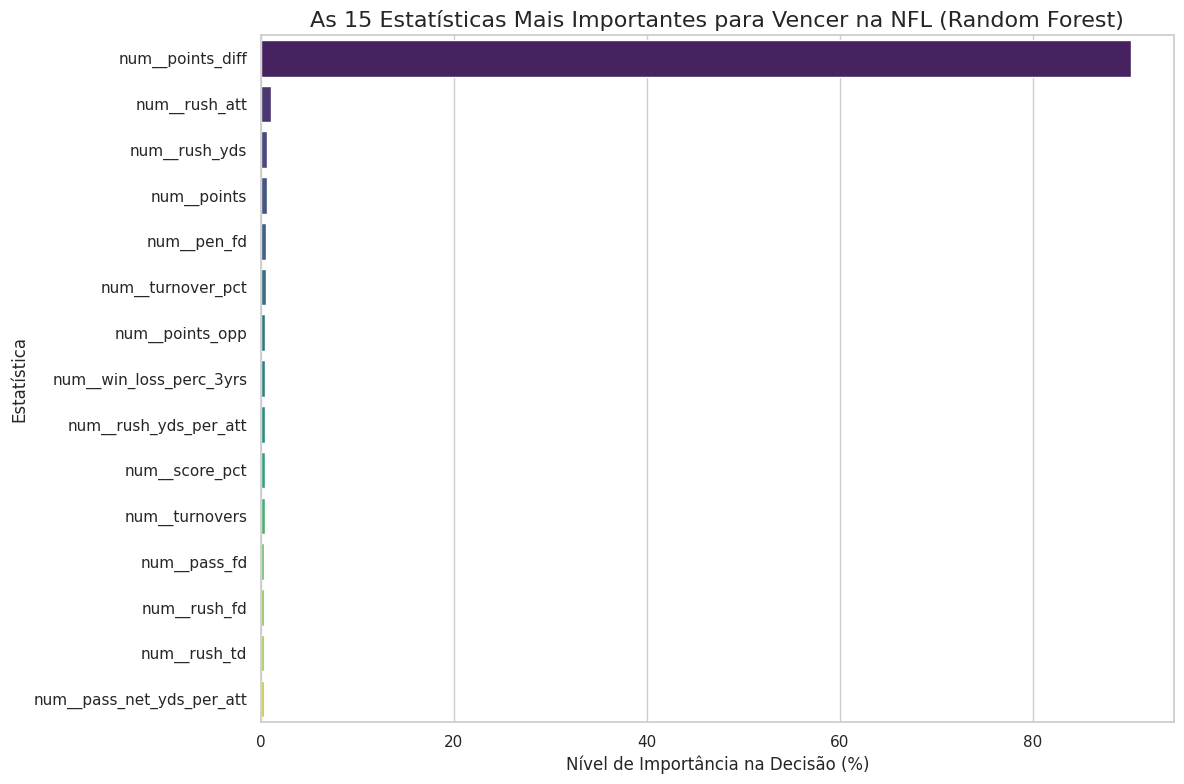

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Extraindo a Importância das Estatísticas do Random Forest...\n")

# Modelo treinado de dentro do pipeline
modelo_rf = melhor_rf.named_steps['model']

# Nome das colunas depois do pré-processamento
nomes_features = melhor_rf.named_steps['preprocessing'].get_feature_names_out()

# Importâncias calculadas pelas árvores
importancias = modelo_rf.feature_importances_

# Tabela com os dados do gráfico
df_importancia = pd.DataFrame({
    'Estatistica': nomes_features,
    'Importancia (%)': importancias * 100 # Multiplica por 100 para ficar em porcentagem
})

df_importancia = df_importancia.sort_values(by='Importancia (%)', ascending=False)

# Gráfico de barras com as 15 estatísticas mais vitais
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importancia (%)',
    y='Estatistica',
    data=df_importancia.head(15),
    palette='viridis'
)

plt.title('As 15 Estatísticas Mais Importantes para Vencer na NFL (Random Forest)', fontsize=16)
plt.xlabel('Nível de Importância na Decisão (%)', fontsize=12)
plt.ylabel('Estatística', fontsize=12)
plt.tight_layout()
plt.show()